# Healthcare Insurance Data Analysis

## Project Aim

This project analyses a healthcare insurance dataset obtained from Kaggle to investigate how personal, lifestyle and geographic factors are associated with medical insurance charges.

The analysis focuses on age, sex, BMI, number of children, smoking status, region and insurance charges.

## Objectives

- Investigate and understand the healthcare insurance dataset.
- Prepare and clean the data for analysis.
- Explore the numerical and categorical variables.
- Investigate the distribution of insurance charges.
- Use appropriate data visualisations to explore relationships between insurance charges and other variables.
- Interpret the findings from the analysis and visualisations.
- Summarise the main findings and conclusions.

## Dataset

The dataset used in this project was obtained from Kaggle. It contains information about personal attributes, lifestyle factors and geographic factors in relation to medical insurance charges.

The dataset contains the following variables:

- Age
- Sex
- BMI
- Number of children
- Smoking status
- Region
- Insurance charges

## Inputs

- `insurance.csv` — the healthcare insurance dataset obtained from Kaggle.

## Outputs

- Cleaned and analysed healthcare insurance data.
- Data visualisations showing the distribution of insurance charges and relationships with other variables.
- Interpretations and conclusions based on the analysis.

## Tools and Libraries

The project uses Python and data analysis and visualisation libraries including:

- Pandas for data manipulation and analysis.
- NumPy for numerical operations.
- Matplotlib for data visualisation.
- Seaborn for statistical data visualisation.
- Plotly for interactive visualisations.

# Section 1: Data Investigation, ETL and Data Cleaning

### Pandas version 3.0.5

I imported Pandas because it will be used to load, clean and analyse
the healthcare insurance dataset.

I also checked the installed Pandas version to record the software
environment used for this project.

In [2]:
# Import Pandas for data analysis
import pandas as pd

# Check the installed Pandas version
print(pd.__version__)

3.0.5


### Loading the dataset

I loaded the healthcare insurance CSV file into a Pandas DataFrame
called `df`. A DataFrame organises data into rows and columns,
making it suitable for data exploration and analysis.

In [3]:
# Load the healthcare insurance dataset
df = pd.read_csv("insurance.csv")

### Initial preview of the dataset

The first five rows were displayed using `df.head()` to confirm that
the dataset was loaded successfully. The dataset contains information
about age, sex, BMI, number of children, smoking status, geographic
region and medical insurance charges.

The preview provides an initial understanding of the variables that
will be investigated during the analysis.

In [6]:
# Display the first five rows of the dataset

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Understanding the DataFrame

The `df.info()` method is used to get a summary of the DataFrame. It shows the number of rows and columns, the column names, the number of non-null values, and the data type of each column.

The dataset contains 1,338 rows and 7 columns. All columns have 1,338 non-null values, which means there are no missing values in the dataset.

The data types show that `age` and `children` are integers, `bmi` and `charges` are floating-point numbers, and `sex`, `smoker`, and `region` contain text data.

This initial check helps identify the structure of the dataset and whether there are any missing values or data types that may need to be addressed during data cleaning.


In [6]:
# Display information about the dataset structure and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### Checking for Missing Values

Missing values can affect the accuracy of data analysis and may need to be handled before analysing the dataset.

I will check each column for missing values to determine whether any records require further cleaning.

Though df.info() checks and tells about missing data, i am still running the missing value code as the data cleaning process.

The `isnull().sum()` method counts the number of missing values in each column.


In [ ]:
# Check for missing values in each column

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

**The result shows that there are no missing values in the dataset, so no missing data needs to be filled or removed.**

### Checking for Duplicate Rows

The `df.duplicated().sum()` method is used to check whether the DataFrame contains any completely duplicated rows.

The result shows that there is 1 duplicate row in the dataset. Identifying duplicate records is an important part of data cleaning because duplicate rows can affect the accuracy of the analysis.


In [ ]:
# Check how many duplicate rows are in the data

df.duplicated().sum()

np.int64(1)

### Inspecting the Duplicate Row

The `df[df.duplicated()]` method is used to display the rows that have been identified as duplicates.

This allows me to inspect the duplicated record before deciding whether it should be removed from the dataset.


In [ ]:
# Show the actual duplicate rows

df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631



### Confirming Duplicate Records

The `df[df.duplicated(keep=False)]` method is used to display all rows that are part of a duplicate, including the original and the duplicated record.

Using `keep=False` allows both identical rows to be displayed so that I can confirm that the records are complete duplicates before deciding whether to remove them.

This provides an additional check before making changes to the dataset.


In [ ]:
# Display all rows that are duplicated, including both the original and duplicate rows,
# so we can identify and review duplicate records before removing them.

df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


### Removing the Duplicate Row

The inspection confirms that the records at index 195 and index 581 contain exactly the same values. Therefore, one of the duplicate records can be removed to prevent the duplicate data from affecting the analysis.

The `drop_duplicates()` method is used to remove duplicate rows from the DataFrame.


In [12]:
# Remove duplicate rows from the dataset so each record is represented only once.

df = df.drop_duplicates()

### Verifying Duplicate Removal

After removing the duplicate row, I will check the DataFrame again to confirm that no duplicate rows remain.

The `df.duplicated().sum()` method is used to count the remaining duplicate rows. A result of 0 will confirm that the duplicate has been successfully removed.


In [ ]:
# Count the number of duplicate rows to identify repeated records in the dataset.

df.duplicated().sum()

np.int64(0)

In [14]:
# Check the DataFrame shape to confirm how many rows and columns remain after removing duplicates.

df.shape

(1337, 7)

### Dataset Dimensions After Cleaning

The `shape` attribute was used to confirm the number of rows and columns remaining after data cleaning. The dataset contains    1,337 rows and 7 columns after removing the duplicate record.

### Checking Categorical Values

The categorical columns contain text values rather than numerical measurements. I will check the unique values in these columns to identify any unexpected or inconsistent entries that may need cleaning.

This check helps confirm that the values are consistent and suitable for analysis.


In [ ]:
# Display the unique values in the sex column to identify the categories present in the dataset.

df['sex'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

 **The sex column contains two consistent values, female and male, so no cleaning is required for this column.**

 **Next I will check the unique values in the smoker column to identify any unexpected or inconsistent entries.**

In [ ]:
# Display the unique values in the smoker column to identify the categories present in the dataset.

df['smoker'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

 **The smoker column contains only yes and no, so no cleaning is required.**

In [ ]:
# Display the unique values in the region column to identify the geographical categories present in the dataset.

df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

 **The region column contains four consistent values, so no cleaning is required.**

### Note on additional uniqueness checks

I did not use `df['children'].unique()` or `df.nunique()` at this stage. Although these functions could provide additional information about the dataset, they were not necessary for the current data-quality assessment. The range and distribution of the `children` variable were already covered by `df.describe()`, while `df['sex'].unique()`, `df['smoker'].unique()`, and `df['region'].unique()` directly identified the categories needed for checking the categorical variables.

### Checking Age Values

**The `age` column contains numerical values. I will check the minimum and maximum age to identify any values that may be outside a sensible range or require further investigation.This also helps to identify the youngest and oldest individuals included in the insurance data .**


In [ ]:
# Check the minimum and maximum age to understand the age range represented in the dataset.

df['age'].min(), df['age'].max()

(np.int64(18), np.int64(64))

**The age values range from 18 to 64, which is a sensible range for the adult insurance dataset,  and no obviously invalid age values were identified. Therefore, no cleaning is required for the age column.**


### Checking BMI Values

**The `bmi` column contains numerical values. I will check the minimum and maximum BMI values to identify any values that may be outside a plausible range or require further investigation.**


In [ ]:
# Check the minimum and maximum BMI values to understand the BMI range represented in the dataset.

df['bmi'].min(), df['bmi'].max()

(np.float64(15.96), np.float64(53.13))

 **The BMI values range from 15.96 to 53.13. These are plausible recorded BMI values, so no obviously invalid values were identified and no cleaning is required for the bmi column.**

### Checking Children Values

**The children column contains numerical values. I will check the minimum and maximum number of children to identify any values that may be invalid or require further investigation.**


In [ ]:
# Check the minimum and maximum number of children to understand the range of this variable in the dataset.

df['children'].min(), df['children'].max()

(np.int64(0), np.int64(5))


**The number of children ranges from 0 to 5. These are plausible values, so no obviously invalid values were identified and no cleaning is required for the children column.**




### Checking Charges Values

**The `charges` column contains the insurance charges as numerical values. I will check the minimum and maximum charges to identify any values that may be invalid or require further investigation.**


In [ ]:
# Check the minimum and maximum insurance charges to understand the range of costs recorded in the dataset.

df['charges'].min(), df['charges'].max()

(np.float64(1121.8739), np.float64(63770.42801))

**The insurance charges range from 1,121.8739 to 63,770.42801. All values are positive, so no obviously invalid values were identified and no cleaning is required for the `charges` column.**



### Descriptive Statistics

df.describe() is a Pandas method for descriptive statistics, it gives a statistical summary of my numerical columns.
Descriptive statistics provide a summary of the numerical columns in the dataset. They help us understand the distribution and general characteristics of variables such as age, BMI, number of children, and insurance charges.


In [ ]:
# Generate descriptive statistics for the numerical variables to understand their central tendency, spread, and range.

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**The descriptive statistics provide an overview of the numerical variables. After removing the duplicate record, the dataset contains 1,337 records. The summary shows the central values and ranges of age, BMI, children, and insurance charges, which will help guide the next stage of the analysis.**


## Project Purpose and Research Questions

### Project Purpose

The purpose of this project is to analyse healthcare insurance data to identify factors that are associated with differences in insurance charges. The analysis will explore personal, lifestyle and geographic factors such as age, BMI, smoking status, number of children and region.

The findings are intended to help healthcare insurance stakeholders and data analysts better understand patterns in insurance costs and support evidence-based decision-making.

### Target Audience

The primary target audience is healthcare insurance stakeholders and data analysts who may use data-driven insights to understand factors associated with healthcare insurance costs.

### Research Questions

1. What is the distribution of healthcare insurance charges in the dataset?
2. How does smoking status relate to insurance charges?
3. Is there a relationship between BMI and insurance charges?
4. How does age relate to insurance charges?
5. Do insurance charges differ between geographic regions?
6. How are age, BMI, children and insurance charges related to each other?


### Development Challenge: Python Environment and Visualisation Libraries

During the development of this project, I encountered several technical issues when preparing the Python environment for data visualisation.

When I first attempted to create a histogram using Pandas, the notebook reported that Matplotlib was required. Further investigation showed that different Python virtual environments were being used by the development environment.

I also identified an incompatible NumPy installation. The error message showed that compiled NumPy files were built for Python 3.14 while the project was running Python 3.12. This prevented NumPy and dependent libraries from importing correctly.


To resolve these issues, I used the project's Python 3.12 virtual environment and reinstalled the required packages. NumPy, Pandas and Matplotlib were then tested directly in the project environment to confirm that they could be imported successfully. Pillow and kiwisolver, which are dependencies of Matplotlib, also required reinstallation.

These troubleshooting steps improved the reliability of the development environment and demonstrated the process of identifying, investigating and resolving errors rather than ignoring them.

The main data-analysis tools used in this project are Python, Pandas, NumPy and Matplotlib. Additional libraries will be introduced only when they are required for the analysis.

In [ ]:

# Display the path of the Python executable currently being used by the notebook.
import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Documents\Pandas_Learning\.venv_pandas\Scripts\python.exe


### Python Executable Path
Notebook was initially using this path

Why I checked sys.executable again: 
Troubleshooting the Python environment and needed to confirm the final interpreter being used by the capstone notebook,is using Healthcare_Insurance_capstone.venv,which is the virtual environment I created for this project work.

In [ ]:
# Check the Python executable again after changing the environment to confirm which Python interpreter the notebook is using.

import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Desktop\Healthcare_Insurance_Capstone\.venv-2\Scripts\python.exe


In [ ]:
# Verify the Python executable currently selected for the capstone notebook after changing the project environment to ensure the correct interpreter is being used.

import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Desktop\Healthcare_Insurance_Capstone\.venv\Scripts\python.exe


### Python Environment Verification

The Python environment was checked several times during the project setup using `sys.executable`. This was necessary because the notebook was using different Python environments during troubleshooting. Checking `sys.executable` allowed me to identify exactly which Python interpreter was being used by the notebook and confirm that the capstone project was connected to the intended environment.

These checks were part of the project setup and troubleshooting process rather than the data analysis itself. They helped ensure that the required Python libraries, including Pandas, NumPy and Matplotlib, were installed and available in the environment being used by the capstone notebook.

In [6]:
import matplotlib
print(matplotlib.__version__)

3.11.1


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Section 2: Data Visualisation and Analysis

## Section Overview

This section uses data visualisation to explore the distribution of healthcare insurance charges and investigate relationships between insurance charges and other variables in the dataset. The visualisations will be used to identify patterns and trends and support the interpretation of the data.

### Matplotlib Visualisation Method Used

The visualisations in this section use different Python data visualisation approaches. The histogram and bar chart below are created using Pandas plotting, which uses Matplotlib as the underlying visualisation library.

| Visualisation | Method Used | Library |

| Histogram | `df['charges'].plot(kind='hist', bins=30)` | Pandas plotting → Matplotlib |
| Bar chart | `df.groupby("smoker")["charges"].mean().plot(kind="bar")` | Pandas plotting → Matplotlib |

These visualisations are used to explore the distribution of insurance charges and compare average insurance charges between smoking-status groups. Further visualisations in this section will use Seaborn and Plotly to demonstrate different visualisation techniques.

### Why a Histogram?

A histogram is used here to show how insurance charges are distributed across all individuals in the dataset. It groups charges into ranges (bins) and shows how many people fall into each range, making it easy to see whether charges are mostly low, high, or spread out evenly, and to spot any skew or outliers in the data.

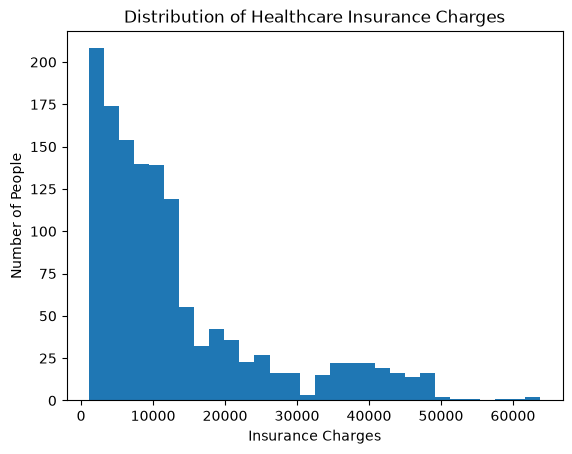

In [ ]:

# Create a histogram to examine the distribution and frequency of healthcare insurance charges.
# kind='hist' tells Pandas to create a histogram.
# bins=30 divides the range of insurance charges into 30 intervals (bins) so you can see how frequently charges occur across different ranges.


df["charges"].plot(kind="hist", bins=30)

# Label the x-axis to show the insurance charge values.
plt.xlabel("Insurance Charges")

# Label the y-axis to show the frequency of observations.
plt.ylabel("Number of People")

# Add a descriptive title to the histogram.
plt.title("Distribution of Healthcare Insurance Charges")

# Display the completed histogram.
plt.show()

### Interpretation of Insurance Charge Distribution using Histogram:

The histogram shows that most people in the dataset have relatively low insurance charges.

There are fewer people with higher insurance charges, and only a small number of people have very high charges. This creates a long tail on the right side of the histogram, which means the data is right-skewed.

The high charges are important because they can increase the overall average (mean) insurance charge. Therefore, it is useful to look at both the mean and the median when understanding the typical insurance cost.

### Comparing Average Charges by Smoking Status

I used `groupby()` to separate the data into smokers and non-smokers. I then used `mean()` to calculate the average insurance charge for each group.

This gives us a numerical comparison before creating a **bar chart** to visualise the difference more clearly.

In [ ]:

# Find the average insurance charge for smokers and non-smokers.
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

### Initial Finding: Smoking Status and Insurance Charges

The average insurance charge for non-smokers is approximately 8,434, while the average charge for smokers is approximately 32,050.

This shows a substantial difference in average insurance charges between the two groups. The average charge for smokers is approximately 3.8 times higher than for non-smokers.


This is an initial finding rather than evidence that smoking directly causes higher insurance charges. Other variables in the dataset, such as age, BMI, number of children and region, may also influence insurance costs. Further analysis and visualisation will therefore be used to investigate this relationship.

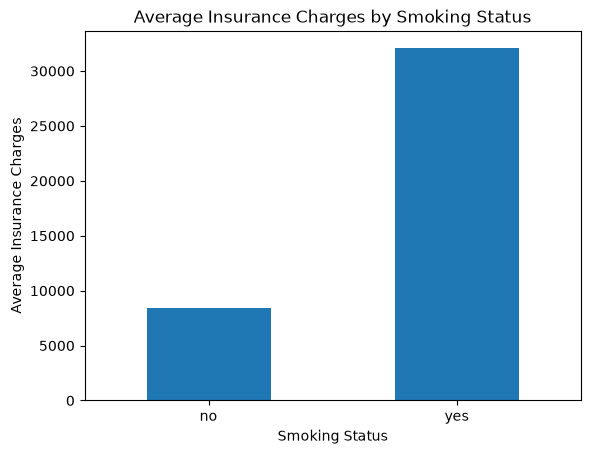

In [ ]:

# Calculate the average insurance charges for each smoking-status category and display the results as a bar chart.
# (.plot(kind="bar")turns the two averages into a bar chart)

df.groupby("smoker")["charges"].mean().plot(kind="bar")


# Label the x-axis to identify the smoking-status categories.

plt.xlabel("Smoking Status")

# Label the y-axis to show the average insurance charges.

plt.ylabel("Average Insurance Charges")

# Add a descriptive title to the chart.

plt.title("Average Insurance Charges by Smoking Status")

# Keep the smoking-status labels horizontal for easier reading.

plt.xticks(rotation=0)

# Display the completed bar chart.

plt.show()

### Interpretation of Average Insurance Charges by Smoking Status using Bar Chart:

The bar chart makes the difference between the two groups easier to see. The smoker bar is much higher than the non-smoker bar.

The bar chart shows a large difference in average insurance charges between smokers and non-smokers.

Non-smokers have an average charge of approximately 8,434, while smokers have an average charge of approximately 32,050.

This means that the average insurance charge for smokers is much higher than for non-smokers in this dataset.

This is an important finding for the insurance industry because smoking status appears to be strongly associated with insurance costs. However, this does not prove that smoking is the only reason for the difference, as other factors such as age, BMI and children may also affect insurance charges.

### Seaborn Visualisation Methods Used


Seaborn is a Python visualisation library built on Matplotlib. It provides statistical charts that are useful for exploring distributions, comparisons and relationships within a dataset.

In this section, Seaborn is used to explore the relationship between age and healthcare insurance charges using a scatter plot and to compare the distribution of healthcare insurance charges across different BMI categories using  a box plot.

Age vs Insurance Charges — scatter plot
   

BMI Categories vs Insurance Charges — box plot

 

### Relationship Between Age and Insurance Charges

A scatter plot is used to investigate the relationship between age and insurance charges. Seaborn is used to visualise the individual observations and identify any patterns or trends between age and insurance costs.

In [6]:
# Import visualization libraries
import seaborn as sns          # for statistical plots (heatmaps, distributions, etc.)
import matplotlib.pyplot as plt # for general plotting and chart customization

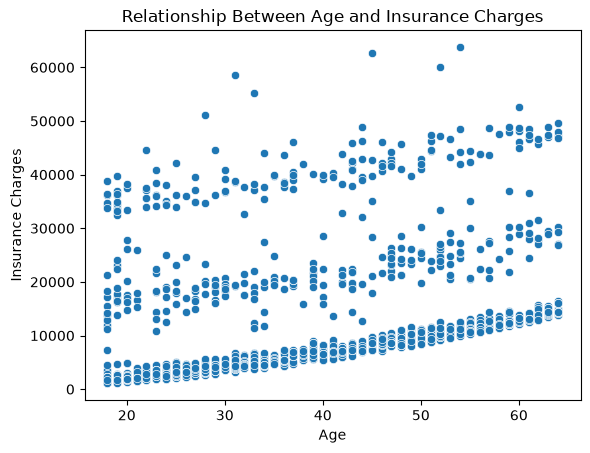

In [ ]:


# Create a Seaborn scatter plot to investigate the relationship between age and insurance charges.
sns.scatterplot(data=df, x="age", y="charges")

# Label the x-axis to show the age of the individuals.
plt.xlabel("Age")

# Label the y-axis to show the insurance charges.
plt.ylabel("Insurance Charges")

# Add a descriptive title to the scatter plot.
plt.title("Relationship Between Age and Insurance Charges")

# Display the completed scatter plot.
plt.show()

### Interpretation of Age and Insurance Charges

The scatter plot shows that insurance charges are widely distributed across different ages. Most observations are concentrated at lower charge levels, while some higher insurance charges occur across the age range.

The relationship between age and insurance charges does not appear to be a simple linear pattern. The wide spread of charges at different ages suggests that other factors in the dataset may also be associated with insurance costs.

This visualisation provides an initial view of the relationship between age and insurance charges, which can be explored further using other variables and visualisations.



### BMI Categories and Insurance Charges

BMI is a numerical variable that can take many different values. To make the comparison easier to interpret, the BMI values are grouped into four standard categories: Underweight, Normal, Overweight and Obese.

A new column called `bmi_category` will be created from the existing `bmi` column. This new categorical variable will then be used to compare insurance charges across the BMI categories.A Seaborn box plot is then used to examine the distribution of insurance charges across the BMI categories.

### Creating the BMI Categories

The `pd.cut()` function is used to divide continuous numerical BMI values into defined ranges. Each range is then given a meaningful category label.

The BMI categories used are:

- Underweight: BMI below 18.5
- Normal: BMI from 18.5 to below 25
- Overweight: BMI from 25 to below 30
- Obese: BMI 30 and above

This creates a new categorical variable called `bmi_category` while keeping the original `bmi` column unchanged.

In [8]:
# Create a new BMI category column by grouping the existing BMI values into defined ranges.
df["bmi_category"] = pd.cut(
    df["bmi"],  # Use the existing BMI values from the DataFrame.
    bins=[0, 18.5, 25, 30, float("inf")],  # Define the boundaries for the four BMI categories.
    labels=["Underweight", "Normal", "Overweight", "Obese"],  # Assign a category label to each BMI range.
    right=False  # Include the lower boundary and exclude the upper boundary of each range.
)

Explaining each code functions:

df["bmi_category"] Creates a new column called bmi_category.

pd.cut() Takes the BMI numbers and puts them into groups/ranges.

df["bmi"] Uses your existing BMI column.

bins Defines where the BMI groups start and finish.

labels Gives each group its name.

right=False Means the lower number belongs to the category, while the upper boundary moves into the next category.

float("inf") Means infinity, so there is no upper limit for the Obese category.

### Checking the New BMI Category Column

The new `bmi_category` column is checked alongside the original BMI values to confirm that the BMI values have been assigned to the appropriate categories.

This is a verification step before creating the visualisation.

In [9]:
# Display the original BMI values and the newly created BMI categories to verify the categorisation.
df[["bmi", "bmi_category"]].head(10)

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight
5,25.740,Overweight
6,33.440,Obese
7,27.740,Overweight
8,29.830,Overweight
9,25.840,Overweight


### Distribution of Insurance Charges by BMI Category

A box plot is used to compare the distribution of insurance charges across the four BMI categories.

The box plot allows the median, spread and potential outliers of insurance charges to be compared between the BMI categories. This provides more information than comparing only the average charge for each category.

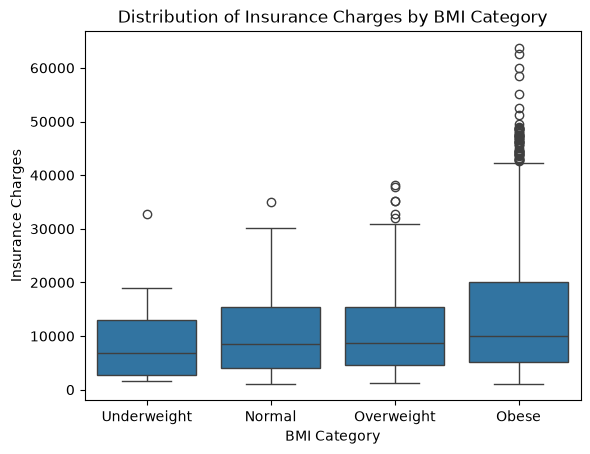

In [10]:
# Create a Seaborn box plot to compare the distribution of insurance charges across BMI categories.
sns.boxplot(data=df, x="bmi_category", y="charges")

# Label the x-axis to identify the BMI categories.
plt.xlabel("BMI Category")

# Label the y-axis to show healthcare insurance charges.
plt.ylabel("Insurance Charges")

# Add a descriptive title to the box plot.
plt.title("Distribution of Insurance Charges by BMI Category")

# Display the completed box plot.
plt.show()

### Interpretation of BMI Categories and Insurance Charges

The box plot shows some differences in insurance charges across the BMI categories. The underweight category generally shows lower charges, while the obese category shows somewhat higher charges.

The normal-weight and overweight categories have relatively similar distributions. Overall, the differences between the BMI categories appear less pronounced than the differences observed between smokers and non-smokers.

This suggests that BMI may be associated with insurance charges, but other factors are also likely to contribute to the variation in costs.